In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_excel(r"D:\CRG\Diageo\For Python.xlsx")

df['Quality'] = df['Quality'].map({'Yes': 1, 'No': 0})

In [3]:
X = df.drop(columns=['Quality', 'Quality2','Mash B#', 'Water Sensory', 'Water pH', 'Water TDS','Water Hardness', 'Water Chloride', 'Water Alkalinity'])
y = df['Quality']

In [4]:
X

,Malt Hot Water Extract 6-Row (pct w by w),Malt Predicted Spirit Yield 6-Row (LA by T,Malt Grist Ratio - Coarse (pct w by w),Malt Grist Ratio - Medium (pct w by w),Malt Grist Ratio - Fine (pct w by w),Malt Moisture (pct),Malt Friability 6-Row,Grist Quantity,Sparging Temperature 1,Sparging Temperature 2,Mash Vessel Turnaround Time,Weak Wort Temperature,Raking Arms Speed,Mashing - Striking Temp.,Draff Loss,Resting Time,Wort Collection - Flow Rate,First Wort Collection - Turbidity,First Wort Collection - Gravity,Ferm. Yeast Addition,CIP Caustic Strength pct,CIP Solution Temperature,CIP Circulation time,CIP FV Contact Time,Yeast Culture Vessel-Wort Initial Gravity,Yeast Culture Vessel-Wort Final Gravity,Yeast count Million cells per ml,Yeast Culture Vessel Cells pct Viability,Fermentation Volume,Ferm. Set-up Temp,Ferm. Set-up Gravity,Ferm. Set-up pH,Ferm. Max. Temp.,Fermentation Time,Total Fermentation Time,Ferm. Wash Final Gravity,Ferm. wash pH,Ferm. Alcohol(pct) 6-Row,Ferm Wash Residual Sugar,WD 1 - Distillation Time,WD - Alcohol pct in Low Wine,WD - Volume Low Wine,SD - Heads Cut Time,SD - Heart Cut Time,SD - Tail Cut Time,SD - Total Distillation Time,SD - Recovery 6-Row,SD - Average Proof FMS
0,74.023745,341.478997,17,76,7,4.67,69.22,8000,78.3,85.4,275,75.7,0.33,65.4,0.40,25,140,255,1.075,3500,2.0,70,20,20,1.065,1.052,260,99,33986,19,1.060,5.26,34,50,68,1,3.48,8.3,0.41,10.00,20.97038,13127,25,210,270,10.00,584.022000,112.8
1,74.036378,341.537275,17,75,8,4.58,70.90,8000,78.5,85.5,280,75.4,0.33,65.8,0.41,25,140,268,1.072,3500,2.2,70,20,20,1.063,1.051,265,99,33988,19,1.060,5.28,33,52,70,1,3.47,8.3,0.40,10.00,20.85610,13138,25,210,240,9.30,584.539750,112.9
2,74.059020,341.641724,17,75,8,4.60,68.88,8000,78.2,85.3,295,76.6,0.33,65.2,0.38,25,140,265,1.072,3500,2.0,70,20,20,1.062,1.052,260,99,33981,18,1.060,5.31,34,52,70,1,3.50,8.3,0.43,10.00,20.91324,13155,25,210,240,9.30,583.645000,113.0
3,74.012442,341.426855,18,75,7,4.66,69.99,8000,78.4,85.3,295,76.6,0.33,66.1,0.39,25,140,270,1.070,3500,2.2,71,20,20,1.059,1.044,255,99,33986,19,1.060,5.28,34,50,72,1,3.49,8.3,0.41,10.00,20.85610,13143,25,210,240,9.30,584.351250,113.0
4,74.515776,343.748786,17,76,7,4.76,70.10,8000,78.5,85.4,285,76.5,0.33,65.5,0.40,25,140,240,1.075,3500,2.0,70,20,20,1.062,1.052,270,99,33985,18,1.060,5.29,33,52,72,1,3.52,8.3,0.48,10.00,20.91324,13126,25,210,250,9.40,583.599000,112.8
5,74.579340,344.042013,18,76,6,4.63,70.21,8000,78.4,85.3,290,76.4,0.33,65.0,0.41,25,140,265,1.071,3500,2.1,70,20,20,1.065,1.054,260,99,33988,19,1.060,5.30,34,54,70,1,3.42,8.3,0.46,10.00,20.97038,13118,25,210,235,9.25,583.786000,112.7
6,74.049859,341.599464,18,75,7,4.71,70.30,8000,78.4,85.4,275,76.5,0.33,65.2,0.38,25,140,270,1.069,3500,2.0,70,20,20,1.063,1.050,270,99,33974,19,1.059,5.25,34,50,72,1,3.49,8.3,0.48,9.30,20.85610,13146,25,210,240,9.30,584.680875,112.9
7,74.061877,341.654904,17,76,7,4.67,69.99,8000,78.6,85.6,300,76.4,0.33,65.1,0.40,25,140,240,1.072,3500,2.2,70,20,20,1.064,1.054,255,99,33983,19,1.060,5.33,34,52,72,1,3.48,8.2,0.44,10.00,20.68468,13139,25,210,240,9.30,585.009750,113.1
8,74.390000,343.168569,18,75,7,4.53,69.28,8000,78.5,85.4,300,76.4,0.33,65.1,0.43,25,140,233,1.070,3500,2.0,70,20,20,1.063,1.050,270,99,33988,18,1.060,5.29,34,52,70,1,3.42,8.3,0.44,10.00,20.85610,13140,25,210,240,9.30,585.009000,112.8
9,74.334346,342.911831,17,75,8,4.43,68.20,8000,78.4,85.4,280,76.3,0.33,65.3,0.45,25,140,250,1.073,3500,2.1,70,20,20,1.065,1.052,265,99,33985,19,1.058,5.28,34,56,72,1,3.46,8.3,0.39,10.00,20.91324,13129,25,210,270,10.00,586.603500,112.7


In [5]:
y

0     0
1     1
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    1
11    1
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    1
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    1
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
Name: Quality, dtype: int64

In [6]:
correlation_matrix = df.corr()

print(correlation_matrix)

                                             Mash B#  \
Mash B#                                     1.000000   
Malt Hot Water Extract 6-Row (pct w by w)  -0.044718   
Malt Predicted Spirit Yield 6-Row (LA by T -0.044718   
Malt Grist Ratio - Coarse (pct w by w)      0.107222   
Malt Grist Ratio - Medium (pct w by w)      0.095535   
Malt Grist Ratio - Fine (pct w by w)       -0.138195   
Malt Moisture (pct)                         0.303391   
Malt Friability 6-Row                       0.052154   
Water Sensory                                    NaN   
Water pH                                    0.374014   
Water TDS                                   0.782777   
Water Hardness                             -0.437165   
Water Chloride                              0.588464   
Water Alkalinity                           -0.643227   
Grist Quantity                                   NaN   
Sparging Temperature 1                      0.093482   
Sparging Temperature 2                      0.07

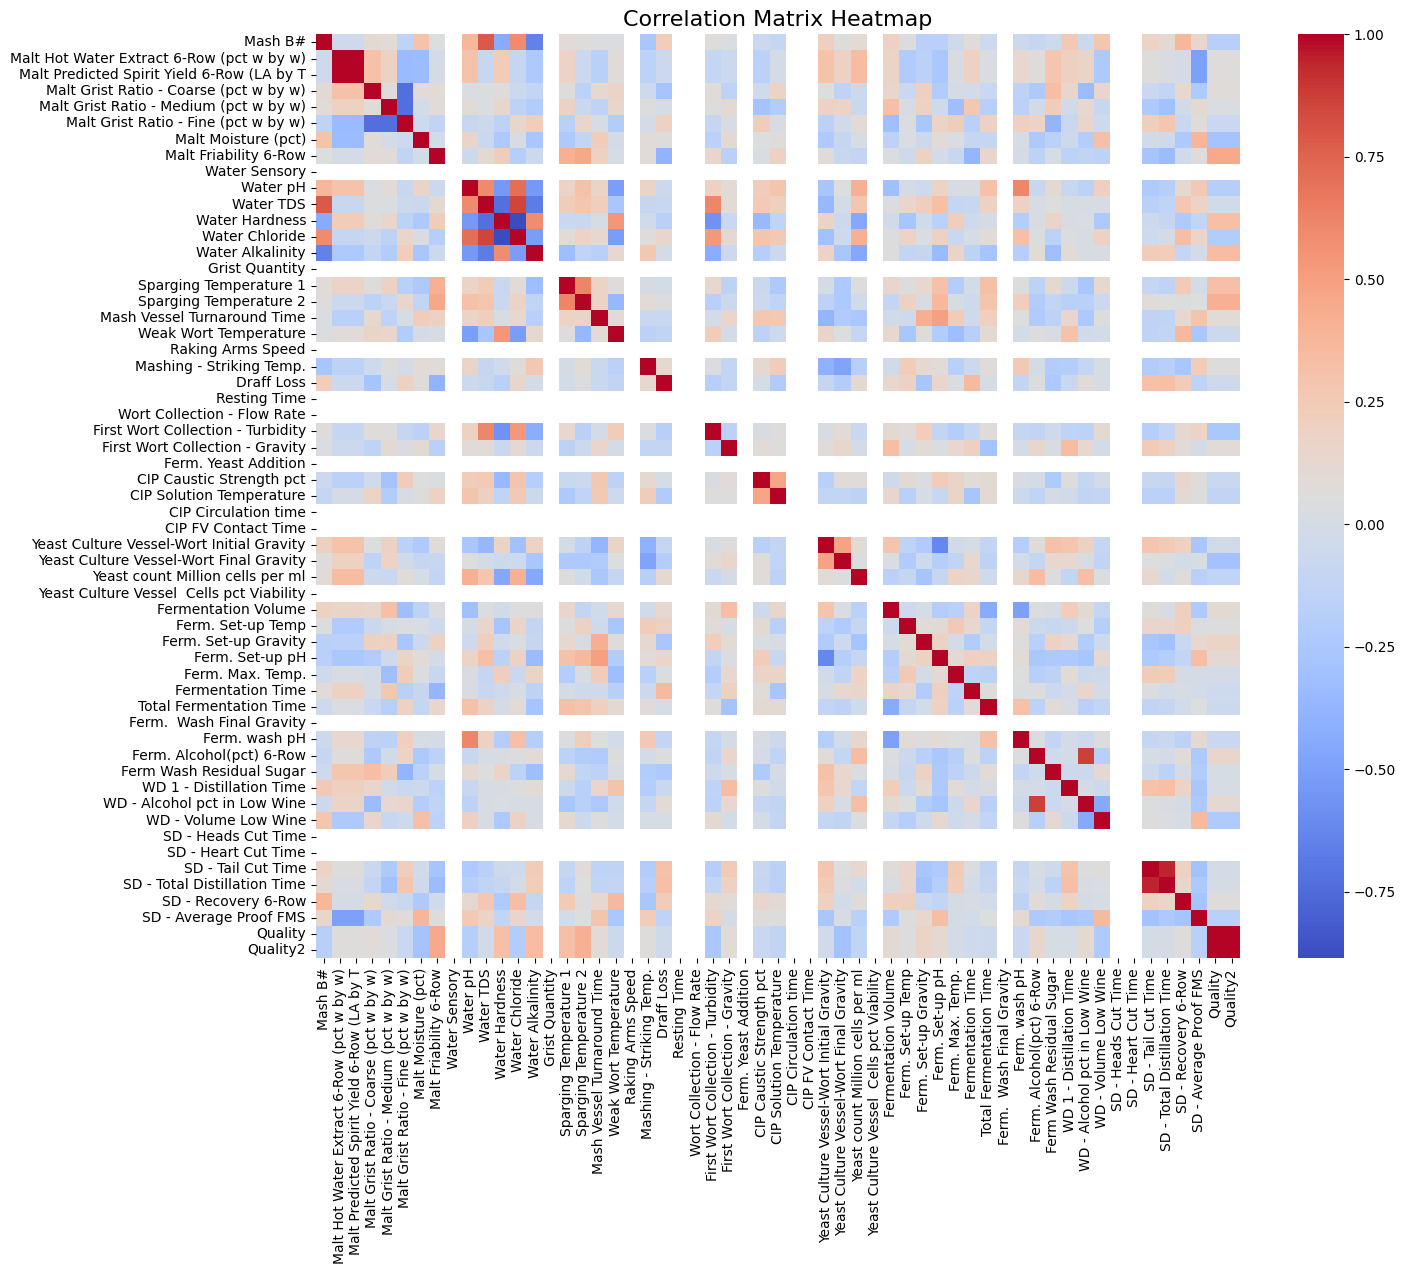

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))  # Adjust the size as needed
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', square=True, cbar=True)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

In [8]:
threshold = 0

highly_correlated_with_quality = []
for column in correlation_matrix.columns:
    if column != 'quality':
        correlation_value = correlation_matrix.loc['Quality', column]
        if abs(correlation_value) > threshold:
            highly_correlated_with_quality.append((column, correlation_value))

highly_correlated_with_quality_df = pd.DataFrame(highly_correlated_with_quality, columns=['Feature', 'Correlation with Quality'])

print("Highly correlated features with 'quality' (correlation > 0.2):")
print(highly_correlated_with_quality_df)

Highly correlated features with 'quality' (correlation > 0.2):
                                       Feature  Correlation with Quality
0                                      Mash B#                 -0.182683
1    Malt Hot Water Extract 6-Row (pct w by w)                  0.066042
2   Malt Predicted Spirit Yield 6-Row (LA by T                  0.066042
3       Malt Grist Ratio - Coarse (pct w by w)                  0.083650
4       Malt Grist Ratio - Medium (pct w by w)                  0.029306
5         Malt Grist Ratio - Fine (pct w by w)                 -0.077106
6                          Malt Moisture (pct)                 -0.288622
7                        Malt Friability 6-Row                  0.452002
8                                     Water pH                 -0.189831
9                                    Water TDS                 -0.029819
10                              Water Hardness                  0.326860
11                              Water Chloride               

In [9]:
highly_correlated_with_quality_df

,Feature,Correlation with Quality
0,Mash B#,-0.182683
1,Malt Hot Water Extract 6-Row (pct w by w),0.066042
2,Malt Predicted Spirit Yield 6-Row (LA by T,0.066042
3,Malt Grist Ratio - Coarse (pct w by w),0.083650
4,Malt Grist Ratio - Medium (pct w by w),0.029306
5,Malt Grist Ratio - Fine (pct w by w),-0.077106
6,Malt Moisture (pct),-0.288622
7,Malt Friability 6-Row,0.452002
8,Water pH,-0.189831
9,Water TDS,-0.029819


In [10]:
highly_correlated_with_quality_df['positive_column'] = highly_correlated_with_quality_df['Correlation with Quality'].abs()  # Get absolute values
highly_correlated_with_quality_df

,Feature,Correlation with Quality,positive_column
0,Mash B#,-0.182683,0.182683
1,Malt Hot Water Extract 6-Row (pct w by w),0.066042,0.066042
2,Malt Predicted Spirit Yield 6-Row (LA by T,0.066042,0.066042
3,Malt Grist Ratio - Coarse (pct w by w),0.083650,0.083650
4,Malt Grist Ratio - Medium (pct w by w),0.029306,0.029306
5,Malt Grist Ratio - Fine (pct w by w),-0.077106,0.077106
6,Malt Moisture (pct),-0.288622,0.288622
7,Malt Friability 6-Row,0.452002,0.452002
8,Water pH,-0.189831,0.189831
9,Water TDS,-0.029819,0.029819


In [11]:
highly_correlated_with_quality_df=highly_correlated_with_quality_df.drop('Correlation with Quality',axis=1)

In [12]:
highly_correlated_with_quality_df = highly_correlated_with_quality_df.sort_values(by='positive_column', ascending=False)
highly_correlated_with_quality_df

,Feature,positive_column
44,Quality2,1.000000
43,Quality,1.000000
7,Malt Friability 6-Row,0.452002
14,Sparging Temperature 2,0.417282
12,Water Alkalinity,0.346089
10,Water Hardness,0.326860
13,Sparging Temperature 1,0.315697
24,Yeast Culture Vessel-Wort Final Gravity,0.296065
6,Malt Moisture (pct),0.288622
19,First Wort Collection - Turbidity,0.247568


In [13]:
print(X.isnull().sum())
print(y.isnull().sum())

Malt Hot Water Extract 6-Row (pct w by w)     0
Malt Predicted Spirit Yield 6-Row (LA by T    0
Malt Grist Ratio - Coarse (pct w by w)        0
Malt Grist Ratio - Medium (pct w by w)        0
Malt Grist Ratio - Fine (pct w by w)          0
Malt Moisture (pct)                           0
Malt Friability 6-Row                         0
Grist Quantity                                0
Sparging Temperature 1                        0
Sparging Temperature 2                        0
Mash Vessel Turnaround Time                   0
Weak Wort Temperature                         0
Raking Arms Speed                             0
Mashing - Striking Temp.                      0
Draff Loss                                    0
Resting Time                                  0
Wort Collection - Flow Rate                   0
First Wort Collection - Turbidity             0
First Wort Collection - Gravity               0
Ferm. Yeast Addition                          0
CIP Caustic Strength pct                

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

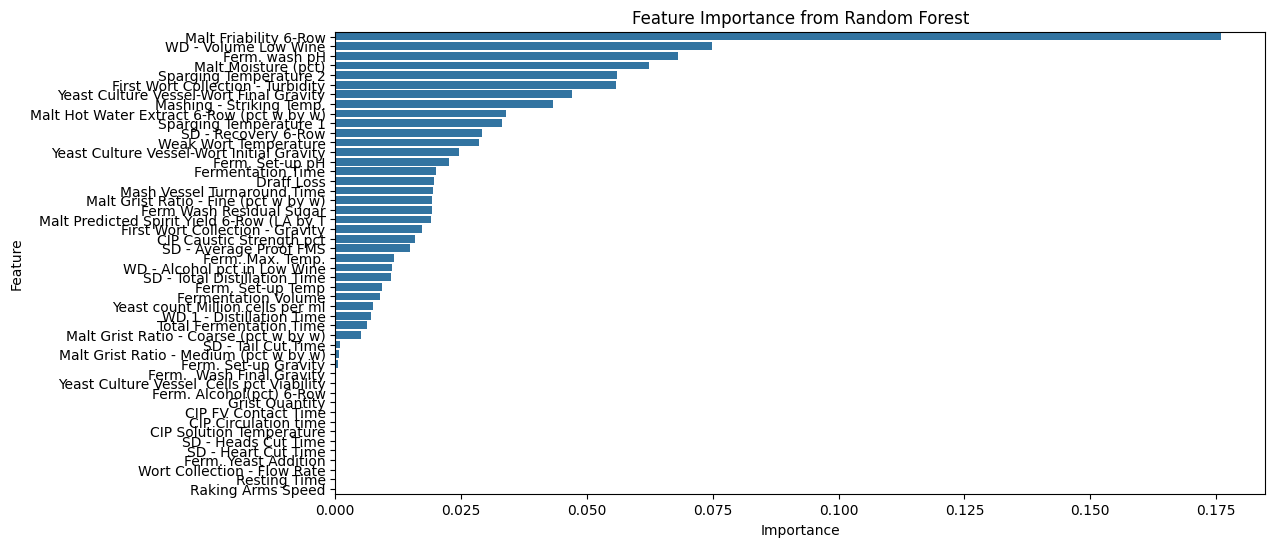

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Fit a Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Get feature importance
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance from Random Forest')
plt.show()

In [19]:
feature_importance

,Feature,Importance
6,Malt Friability 6-Row,0.175964
41,WD - Volume Low Wine,0.074930
36,Ferm. wash pH,0.068015
5,Malt Moisture (pct),0.062247
9,Sparging Temperature 2,0.056024
17,First Wort Collection - Turbidity,0.055740
25,Yeast Culture Vessel-Wort Final Gravity,0.047053
13,Mashing - Striking Temp.,0.043348
0,Malt Hot Water Extract 6-Row (pct w by w),0.033901
8,Sparging Temperature 1,0.033131


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

model = RandomForestClassifier()

# Initialize RFE with the Random Forest model
rfe = RFE(estimator=model, n_features_to_select=1)  # Select 1 feature at a time for ranking
rfe.fit(X_train, y_train)

# Get the feature rankings and support (True for selected, False for not)
ranking = rfe.ranking_
support = rfe.support_

# Get feature importance scores from the model
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

# Create a DataFrame to show features, their ranking, and importance scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': ranking,
    'Importance Score': feature_importances
})

# Sort by importance score descendingly
feature_scores = feature_scores.sort_values(by='Importance Score', ascending=False)

# Print the feature scores
print(feature_scores)

                                       Feature  Ranking  Importance Score
6                        Malt Friability 6-Row        1          0.154144
36                               Ferm. wash pH        7          0.061738
9                       Sparging Temperature 2        9          0.059558
41                        WD - Volume Low Wine        8          0.055212
5                          Malt Moisture (pct)        2          0.054416
17           First Wort Collection - Turbidity        4          0.053510
25     Yeast Culture Vessel-Wort Final Gravity        3          0.045555
46                         SD - Recovery 6-Row       12          0.045010
13                    Mashing - Striking Temp.        6          0.042274
11                       Weak Wort Temperature        5          0.040013
8                       Sparging Temperature 1       11          0.037319
10                 Mash Vessel Turnaround Time       14          0.034316
0    Malt Hot Water Extract 6-Row (pct

In [24]:
"""highly_correlated_with_quality_df, feature_importance, feature_scores"""

'highly_correlated_with_quality_df, feature_importance, feature_scores'

In [26]:
excel_path = r"D:\CRG\Diageo\rfe_feature_scores.xlsx"
feature_scores.to_excel(excel_path, index=False)

In [27]:
excel_path = r"D:\CRG\Diageo\rf_feature_importance.xlsx"
feature_importance.to_excel(excel_path, index=False)

In [28]:
excel_path = r"D:\CRG\Diageo\correlation.xlsx"
highly_correlated_with_quality_df.to_excel(excel_path, index=False)